In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [ ]:
data = pd.read_csv('../../data/raw/heart.csv')

In [3]:
data

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


In [4]:
data.shape

(1025, 14)

In [5]:
data.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [6]:
data.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [7]:
data.nunique()

,0
age,41
sex,2
cp,4
trestbps,49
chol,152
fbs,2
restecg,3
thalach,91
exang,2
oldpeak,40


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [9]:
lst=['sex','cp','fbs','restecg','exang','slope','ca','thal','target']
data[lst] = data[lst].astype(object)

data.dtypes

,0
age,int64
sex,object
cp,object
trestbps,int64
chol,int64
fbs,object
restecg,object
thalach,int64
exang,object
oldpeak,float64


In [10]:
data['sex'] = data['sex'].replace({1: 'Male',
                                   0: 'Female'})
data['cp'] = data['cp'].replace({0: 'typical angina',
                                 1: 'atypical angina',
                                 2: 'non-anginal pain',
                                 3: 'asymtomatic'})
data['fbs'] = data['fbs'].replace({0: 'No',
                                   1: 'Yes'})
data['restecg'] = data['restecg'].replace({0: 'probable or definite left ventricular hypertrophy',
                                           1:'normal',
                                           2: 'ST-T Wave abnormal'})
data['exang'] = data['exang'].replace({0: 'No',
                                       1: 'Yes'})
data['slope'] = data['slope'].replace({0: 'downsloping',
                                       1: 'flat',
                                       2: 'upsloping'})
data['thal'] = data['thal'].replace({1: 'normal',
                                     2: 'fixed defect',
                                     3: 'reversable defect'})
data['ca'] = data['ca'].replace({0: 'Number of major vessels: 0',
                                 1: 'Number of major vessels: 1',
                                 2: 'Number of major vessels: 2',
                                 3: 'Number of major vessels: 3'})
data['target'] = data['target'].replace({0: 'No disease',
                                         1: 'Disease'})

In [11]:
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,Male,typical angina,125,212,No,normal,168,No,1.0,upsloping,Number of major vessels: 2,reversable defect,No disease
1,53,Male,typical angina,140,203,Yes,probable or definite left ventricular hypertrophy,155,Yes,3.1,downsloping,Number of major vessels: 0,reversable defect,No disease
2,70,Male,typical angina,145,174,No,normal,125,Yes,2.6,downsloping,Number of major vessels: 0,reversable defect,No disease
3,61,Male,typical angina,148,203,No,normal,161,No,0.0,upsloping,Number of major vessels: 1,reversable defect,No disease
4,62,Female,typical angina,138,294,Yes,normal,106,No,1.9,flat,Number of major vessels: 3,fixed defect,No disease


In [12]:
numerical_col = data.select_dtypes(include=[np.number])
categorical_col = data.select_dtypes(exclude=[np.number])

In [13]:
for i in categorical_col:
    print("Here is the information: {} = {}".format(i, data[i].unique()))
    print()

Here is the information: sex = ['Male' 'Female']

Here is the information: cp = ['typical angina' 'atypical angina' 'non-anginal pain' 'asymtomatic']

Here is the information: fbs = ['No' 'Yes']

Here is the information: restecg = ['normal' 'probable or definite left ventricular hypertrophy'
 'ST-T Wave abnormal']

Here is the information: exang = ['No' 'Yes']

Here is the information: slope = ['upsloping' 'downsloping' 'flat']

Here is the information: ca = ['Number of major vessels: 2' 'Number of major vessels: 0'
 'Number of major vessels: 1' 'Number of major vessels: 3' 4]

Here is the information: thal = ['reversable defect' 'fixed defect' 'normal' 0]

Here is the information: target = ['No disease' 'Disease']



In [14]:
data['ca'].value_counts()

,count
ca,
Number of major vessels: 0,578
Number of major vessels: 1,226
Number of major vessels: 2,134
Number of major vessels: 3,69
4,18


In [15]:
data[data['ca']==4]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
52,38,Male,non-anginal pain,138,175,No,normal,173,No,0.0,upsloping,4,fixed defect,Disease
83,38,Male,non-anginal pain,138,175,No,normal,173,No,0.0,upsloping,4,fixed defect,Disease
128,52,Male,non-anginal pain,138,223,No,normal,169,No,0.0,upsloping,4,fixed defect,Disease
208,38,Male,non-anginal pain,138,175,No,normal,173,No,0.0,upsloping,4,fixed defect,Disease
242,38,Male,non-anginal pain,138,175,No,normal,173,No,0.0,upsloping,4,fixed defect,Disease
290,52,Male,non-anginal pain,138,223,No,normal,169,No,0.0,upsloping,4,fixed defect,Disease
340,38,Male,non-anginal pain,138,175,No,normal,173,No,0.0,upsloping,4,fixed defect,Disease
348,43,Male,typical angina,132,247,Yes,probable or definite left ventricular hypertrophy,143,Yes,0.1,flat,4,reversable defect,No disease
417,52,Male,non-anginal pain,138,223,No,normal,169,No,0.0,upsloping,4,fixed defect,Disease
428,43,Male,typical angina,132,247,Yes,probable or definite left ventricular hypertrophy,143,Yes,0.1,flat,4,reversable defect,No disease


In [16]:
data.loc[data['ca']==4, 'ca'] = np.nan

In [17]:
data['ca'].value_counts()

,count
ca,
Number of major vessels: 0,578
Number of major vessels: 1,226
Number of major vessels: 2,134
Number of major vessels: 3,69


In [18]:
data['thal'].value_counts()

,count
thal,
fixed defect,544
reversable defect,410
normal,64
0,7


In [19]:
data[data['thal']==0].head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
14,52,Male,typical angina,128,204,Yes,normal,156,Yes,1.0,flat,Number of major vessels: 0,0,No disease
319,53,Female,non-anginal pain,128,216,No,probable or definite left ventricular hypertrophy,115,No,0.0,upsloping,Number of major vessels: 0,0,Disease
329,53,Female,non-anginal pain,128,216,No,probable or definite left ventricular hypertrophy,115,No,0.0,upsloping,Number of major vessels: 0,0,Disease
359,53,Female,non-anginal pain,128,216,No,probable or definite left ventricular hypertrophy,115,No,0.0,upsloping,Number of major vessels: 0,0,Disease
686,52,Male,typical angina,128,204,Yes,normal,156,Yes,1.0,flat,Number of major vessels: 0,0,No disease


In [20]:
data.loc[data['thal']==0, 'thal'] = np.nan

In [21]:
data['thal'].value_counts()

,count
thal,
fixed defect,544
reversable defect,410
normal,64


In [22]:
print("Hasil missing value:\n", data.isnull().sum()/len(data)*100)

Hasil missing value:
 age         0.000000
sex         0.000000
cp          0.000000
trestbps    0.000000
chol        0.000000
fbs         0.000000
restecg     0.000000
thalach     0.000000
exang       0.000000
oldpeak     0.000000
slope       0.000000
ca          1.756098
thal        0.682927
target      0.000000
dtype: float64


In [23]:
data[data.isnull().any(axis=1)].head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
14,52,Male,typical angina,128,204,Yes,normal,156,Yes,1.0,flat,Number of major vessels: 0,NaN,No disease
52,38,Male,non-anginal pain,138,175,No,normal,173,No,0.0,upsloping,NaN,fixed defect,Disease
83,38,Male,non-anginal pain,138,175,No,normal,173,No,0.0,upsloping,NaN,fixed defect,Disease
128,52,Male,non-anginal pain,138,223,No,normal,169,No,0.0,upsloping,NaN,fixed defect,Disease
208,38,Male,non-anginal pain,138,175,No,normal,173,No,0.0,upsloping,NaN,fixed defect,Disease


In [24]:
modus_ca = data['ca'].mode()[0]
data['ca'] = data['ca'].fillna(modus_ca)

modus_thal = data['thal'].mode()[0]
data['thal'] = data['thal'].fillna(modus_thal)

In [25]:
print("Missing value result:\n", data.isnull().sum())

Missing value result:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [26]:
data.duplicated().sum()

np.int64(723)

In [27]:
data[data.duplicated()]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
15,34,Female,atypical angina,118,210,No,normal,192,No,0.7,upsloping,Number of major vessels: 0,fixed defect,Disease
31,50,Female,atypical angina,120,244,No,normal,162,No,1.1,upsloping,Number of major vessels: 0,fixed defect,Disease
43,46,Male,typical angina,120,249,No,probable or definite left ventricular hypertrophy,144,No,0.8,upsloping,Number of major vessels: 0,reversable defect,No disease
55,55,Male,typical angina,140,217,No,normal,111,Yes,5.6,downsloping,Number of major vessels: 0,reversable defect,No disease
61,66,Female,non-anginal pain,146,278,No,probable or definite left ventricular hypertrophy,152,No,0.0,flat,Number of major vessels: 1,fixed defect,Disease
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,Male,atypical angina,140,221,No,normal,164,Yes,0.0,upsloping,Number of major vessels: 0,fixed defect,Disease
1021,60,Male,typical angina,125,258,No,probable or definite left ventricular hypertrophy,141,Yes,2.8,flat,Number of major vessels: 1,reversable defect,No disease
1022,47,Male,typical angina,110,275,No,probable or definite left ventricular hypertrophy,118,Yes,1.0,flat,Number of major vessels: 1,fixed defect,No disease
1023,50,Female,typical angina,110,254,No,probable or definite left ventricular hypertrophy,159,No,0.0,upsloping,Number of major vessels: 0,fixed defect,Disease


In [28]:
data.drop_duplicates(keep="first", inplace=True)
data.duplicated().sum()

np.int64(0)

In [29]:
data.shape

(302, 14)

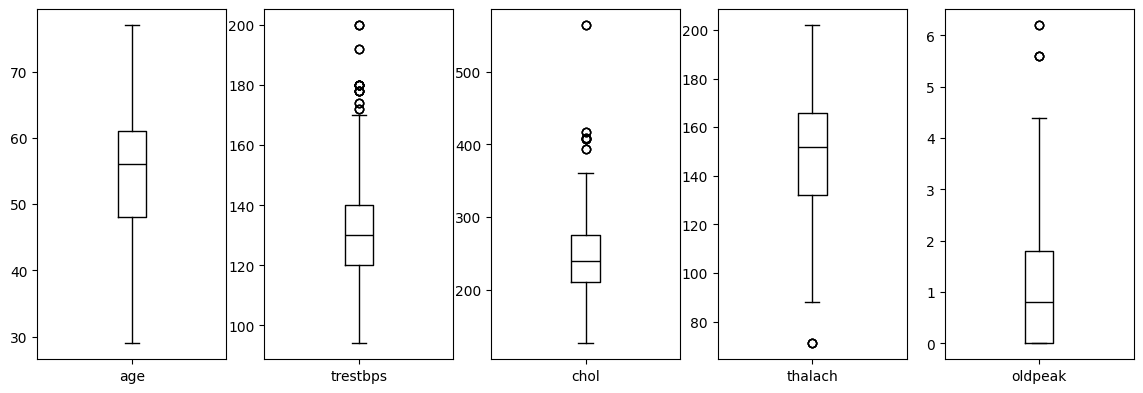

In [30]:
numerical_col.plot(kind = 'box', subplots = True, layout = (2,7), sharex = False, sharey = False, figsize = (20, 10), color = 'k')
plt.show()

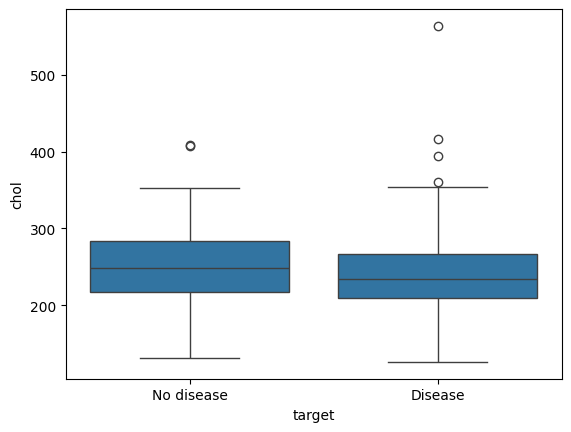

In [31]:
sns.boxplot(x='target', y='chol', data=data)
plt.show()

In [32]:
continous_features = numerical_col.columns
def outliers(data_out, drop = False):
    for each_feature in data_out.columns:
        feature_data = data_out[each_feature]
        Q1 = np.percentile(feature_data, 25.)
        Q3 = np.percentile(feature_data, 75.)
        IQR = Q3-Q1
        outlier_step = IQR * 1.5
        outliers = feature_data[~((feature_data >= Q1 - outlier_step) & (feature_data <= Q3 + outlier_step))].index.tolist()
        if not drop:
            print('For the feature {}, Num of Outliers is {}'.format(each_feature, len(outliers)))
        if drop:
            data.drop(outliers, inplace = True, errors = 'ignore')
            print('Outliers from {} feature removed'.format(each_feature))

outliers(data[continous_features])

For the feature age, Num of Outliers is 0
For the feature trestbps, Num of Outliers is 9
For the feature chol, Num of Outliers is 5
For the feature thalach, Num of Outliers is 1
For the feature oldpeak, Num of Outliers is 5


In [33]:
outliers(data[continous_features], drop=True)

Outliers from age feature removed
Outliers from trestbps feature removed
Outliers from chol feature removed
Outliers from thalach feature removed
Outliers from oldpeak feature removed


In [34]:
outliers(data[continous_features], drop=True)

Outliers from age feature removed
Outliers from trestbps feature removed
Outliers from chol feature removed
Outliers from thalach feature removed
Outliers from oldpeak feature removed


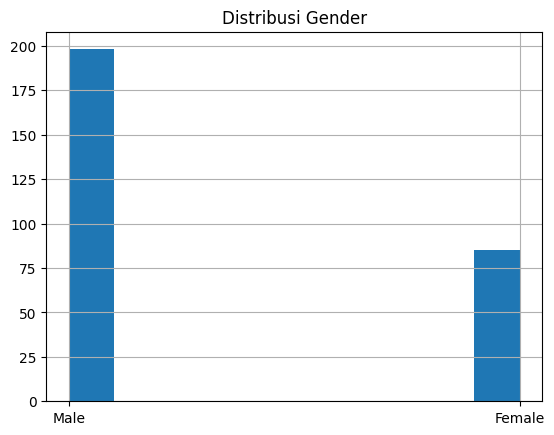

In [35]:
data['sex'].hist().plot(kind='bar')
plt.title('Distribusi Gender')
plt.show()

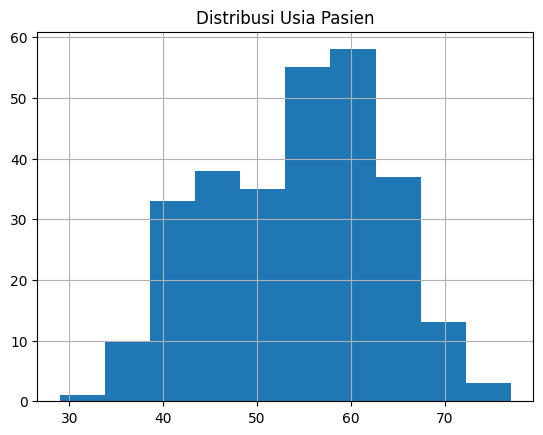

In [36]:
data['age'].hist().plot(kind='bar')
plt.title('Distribusi Usia Pasien')
plt.show()

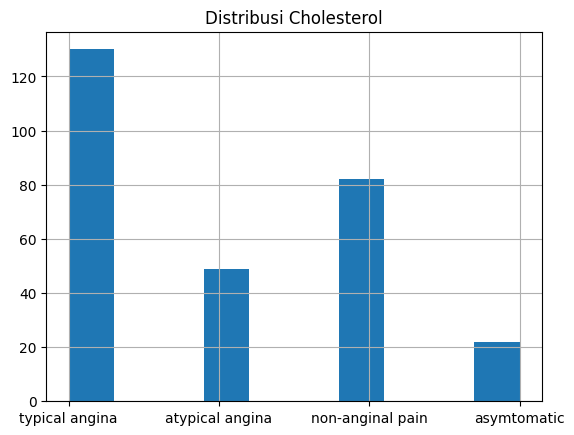

In [37]:
data['cp'].hist().plot(kind='bar')
plt.title('Distribusi Cholesterol')
plt.show()

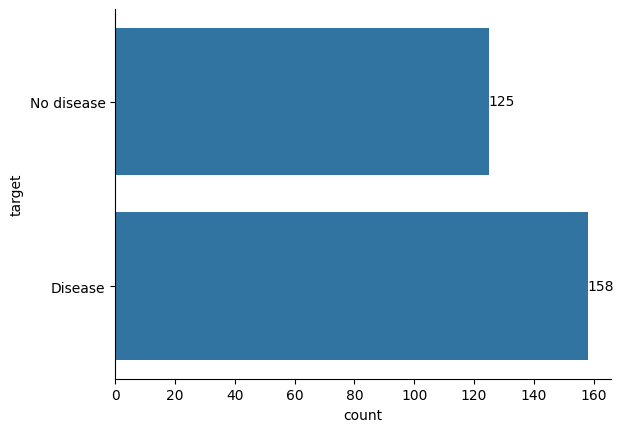

In [38]:
ax = sns.countplot(data['target'])
for label in ax.containers:
    ax.bar_label(label)
sns.despine()
plt.show()

In [39]:
data.describe()

,age,trestbps,chol,thalach,oldpeak
count,283.000000,283.000000,283.000000,283.000000,283.000000
mean,54.049470,129.883392,242.314488,149.961131,0.951943
std,9.128186,15.387795,44.654188,22.691625,1.026400
min,29.000000,94.000000,126.000000,88.000000,0.000000
25%,47.000000,120.000000,210.500000,133.500000,0.000000
50%,55.000000,130.000000,239.000000,153.000000,0.600000
75%,60.000000,140.000000,270.500000,168.000000,1.600000
max,77.000000,170.000000,360.000000,202.000000,4.000000


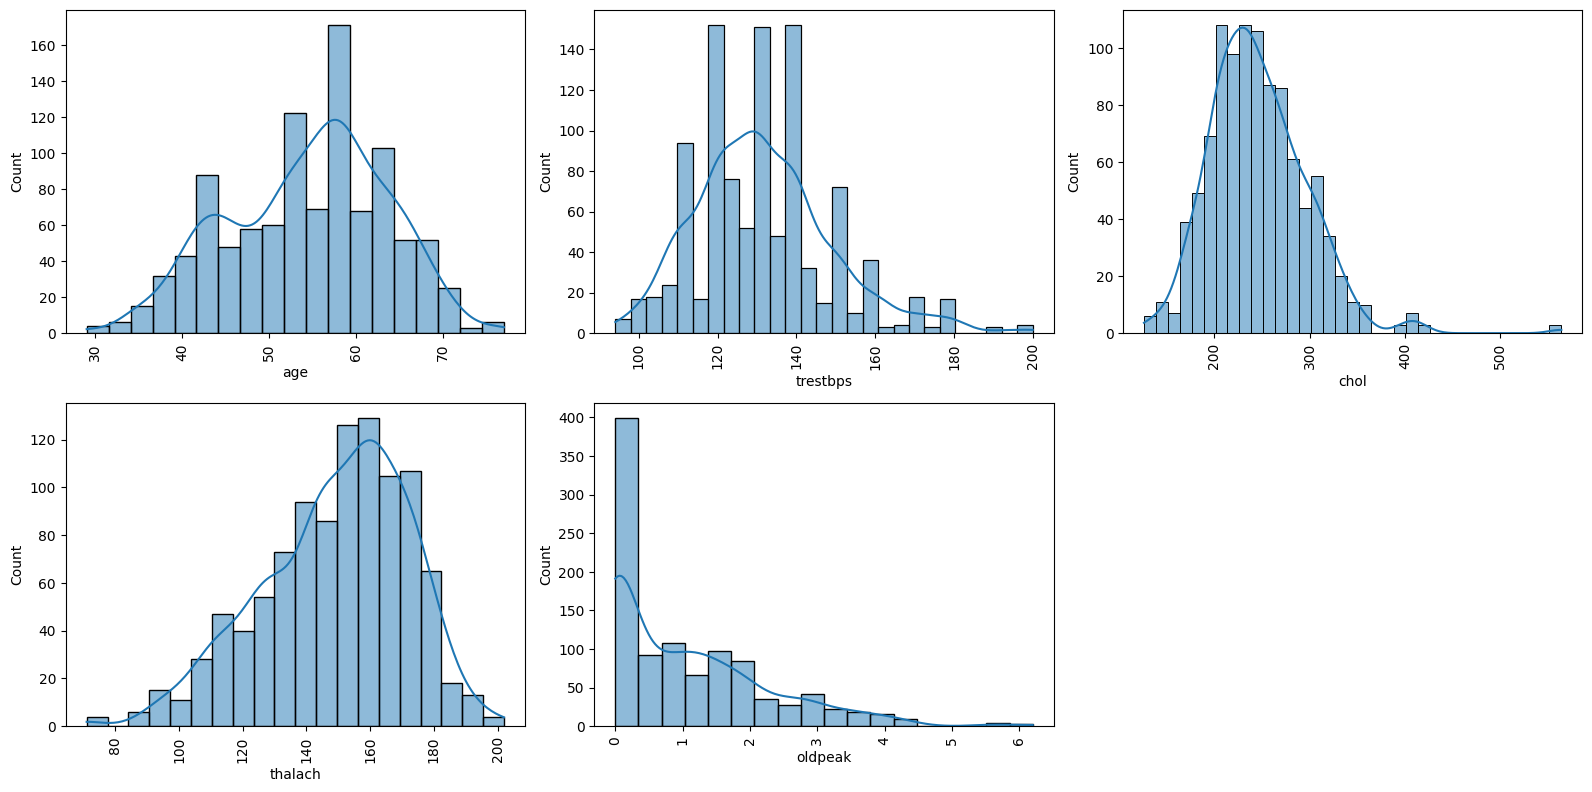

In [40]:
plt.figure(figsize=(16,8))
for index,column in enumerate(numerical_col):
    plt.subplot(2,3,index+1)
    sns.histplot(data=numerical_col,x=column,kde=True)
    plt.xticks(rotation = 90)
plt.tight_layout(pad = 1.0)
plt.show()

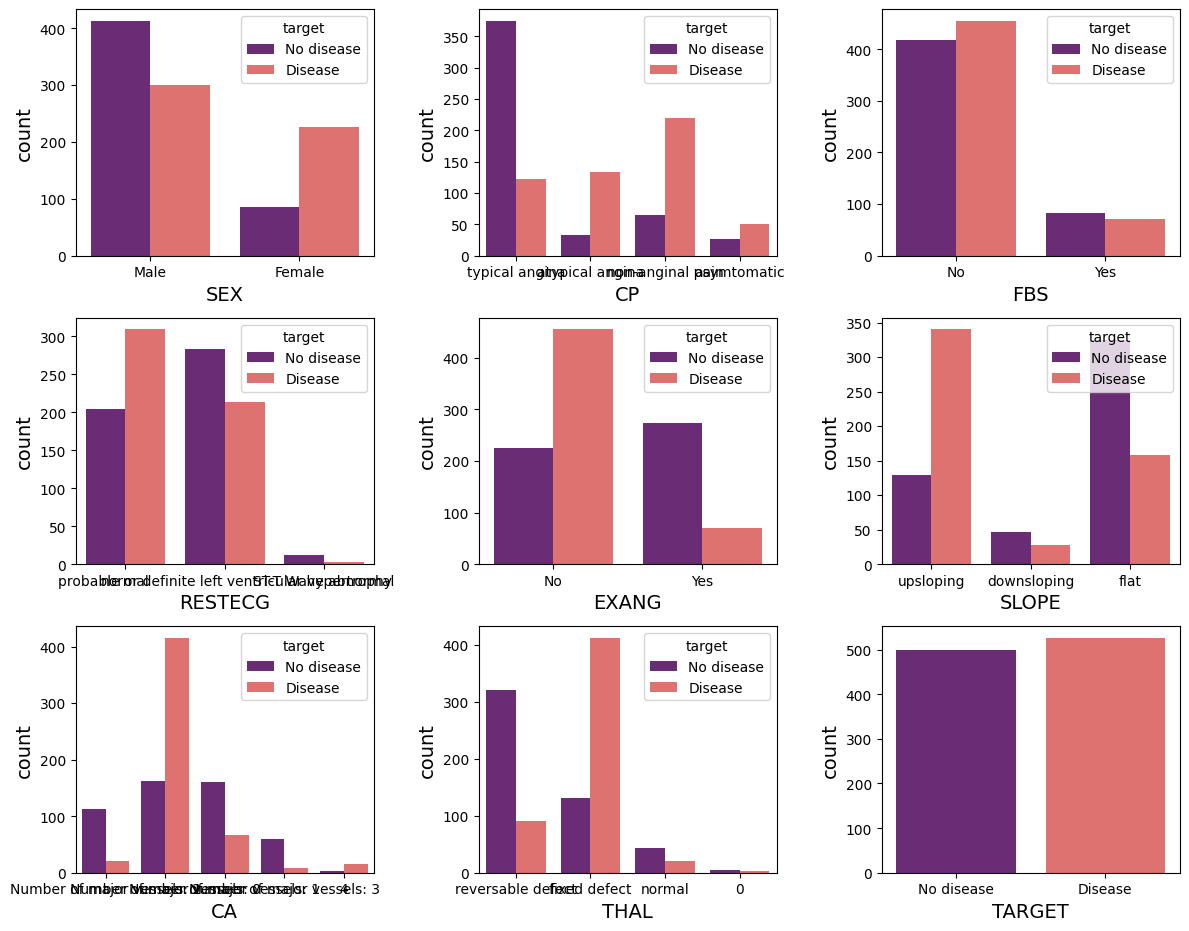

In [41]:
plt.figure(figsize=(12,12))
for index, column in enumerate(categorical_col):
    plt.subplot(4, 3, index+1)
    sns.countplot(data=categorical_col,x=column, hue='target', palette='magma')
    plt.xlabel(column.upper(),fontsize=14)
    plt.ylabel("count", fontsize=14)

plt.tight_layout(pad = 1.0)
plt.show()

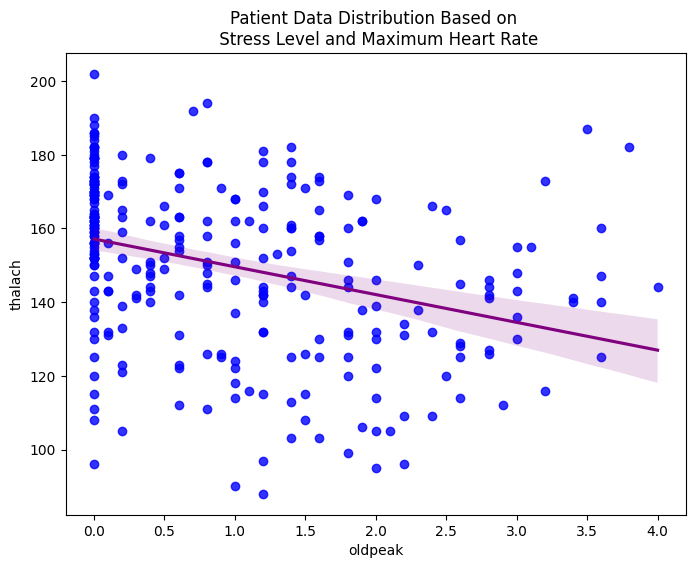

In [42]:
plt.figure(figsize = (8,6))
sns.regplot(data=data, x='oldpeak', y='thalach', scatter_kws = {'color':'blue'}, line_kws = {'color':'purple'})
plt.title('Patient Data Distribution Based on \n Stress Level and Maximum Heart Rate')
plt.show()

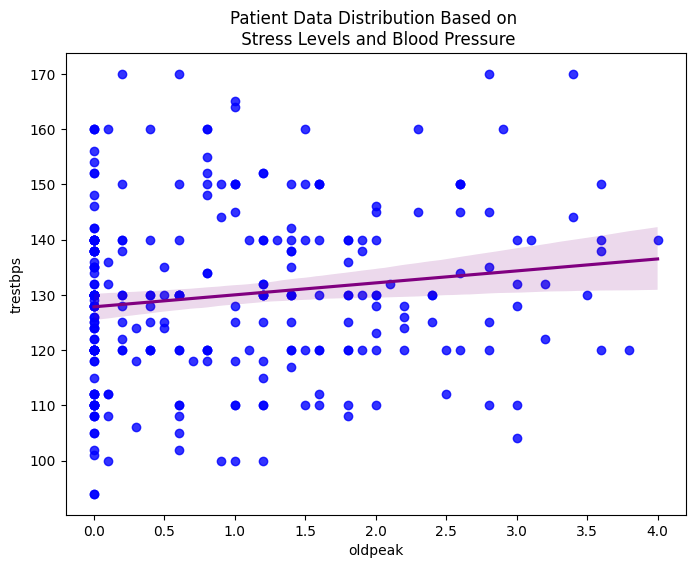

In [43]:
plt.figure(figsize = (8,6))
sns.regplot(data=data, x='oldpeak', y='trestbps', scatter_kws = {'color':'blue'}, line_kws = {'color':'purple'})
plt.title('Patient Data Distribution Based on \n Stress Levels and Blood Pressure')
plt.show()

In [44]:
data.to_csv('data.csv')

df = pd.read_csv('data.csv', index_col=0)
df['sex'] = df['sex'].replace({'Male' : 1,'Female': 0})
df['cp'] = df['cp'].replace({'typical angina' : 0, 'atypical angina' : 1, 'non-anginal pain' : 2, 'asymtomatic' : 3})
df['fbs'] = df['fbs'].replace({'No' : 0, 'Yes' : 1})
df['restecg'] = df['restecg'].replace({'probable or definite left ventricular hypertrophy':0,'normal':1,'ST-T Wave abnormal':2})
df['exang'] = df['exang'].replace({'No':0,'Yes':1})
df['slope'] = df['slope'].replace({'downsloping':0, 'flat':1,'upsloping':2})
df['thal'] = df['thal'].replace({'normal':1, 'fixed defect':2,'reversable defect':3})
df['ca'] = df['ca'].replace({'Number of major vessels: 0':0, 'Number of major vessels: 1':1,'Number of major vessels: 2':2, 'Number of major vessels: 3':3})
df['target'] = df['target'].replace({'No disease':0,'Disease':1})

/tmp/ipython-input-2093197801.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['sex'] = df['sex'].replace({'Male' : 1,'Female': 0})
/tmp/ipython-input-2093197801.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['cp'] = df['cp'].replace({'typical angina' : 0, 'atypical angina' : 1, 'non-anginal pain' : 2, 'asymtomatic' : 3})
/tmp/ipython-input-2093197801.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_

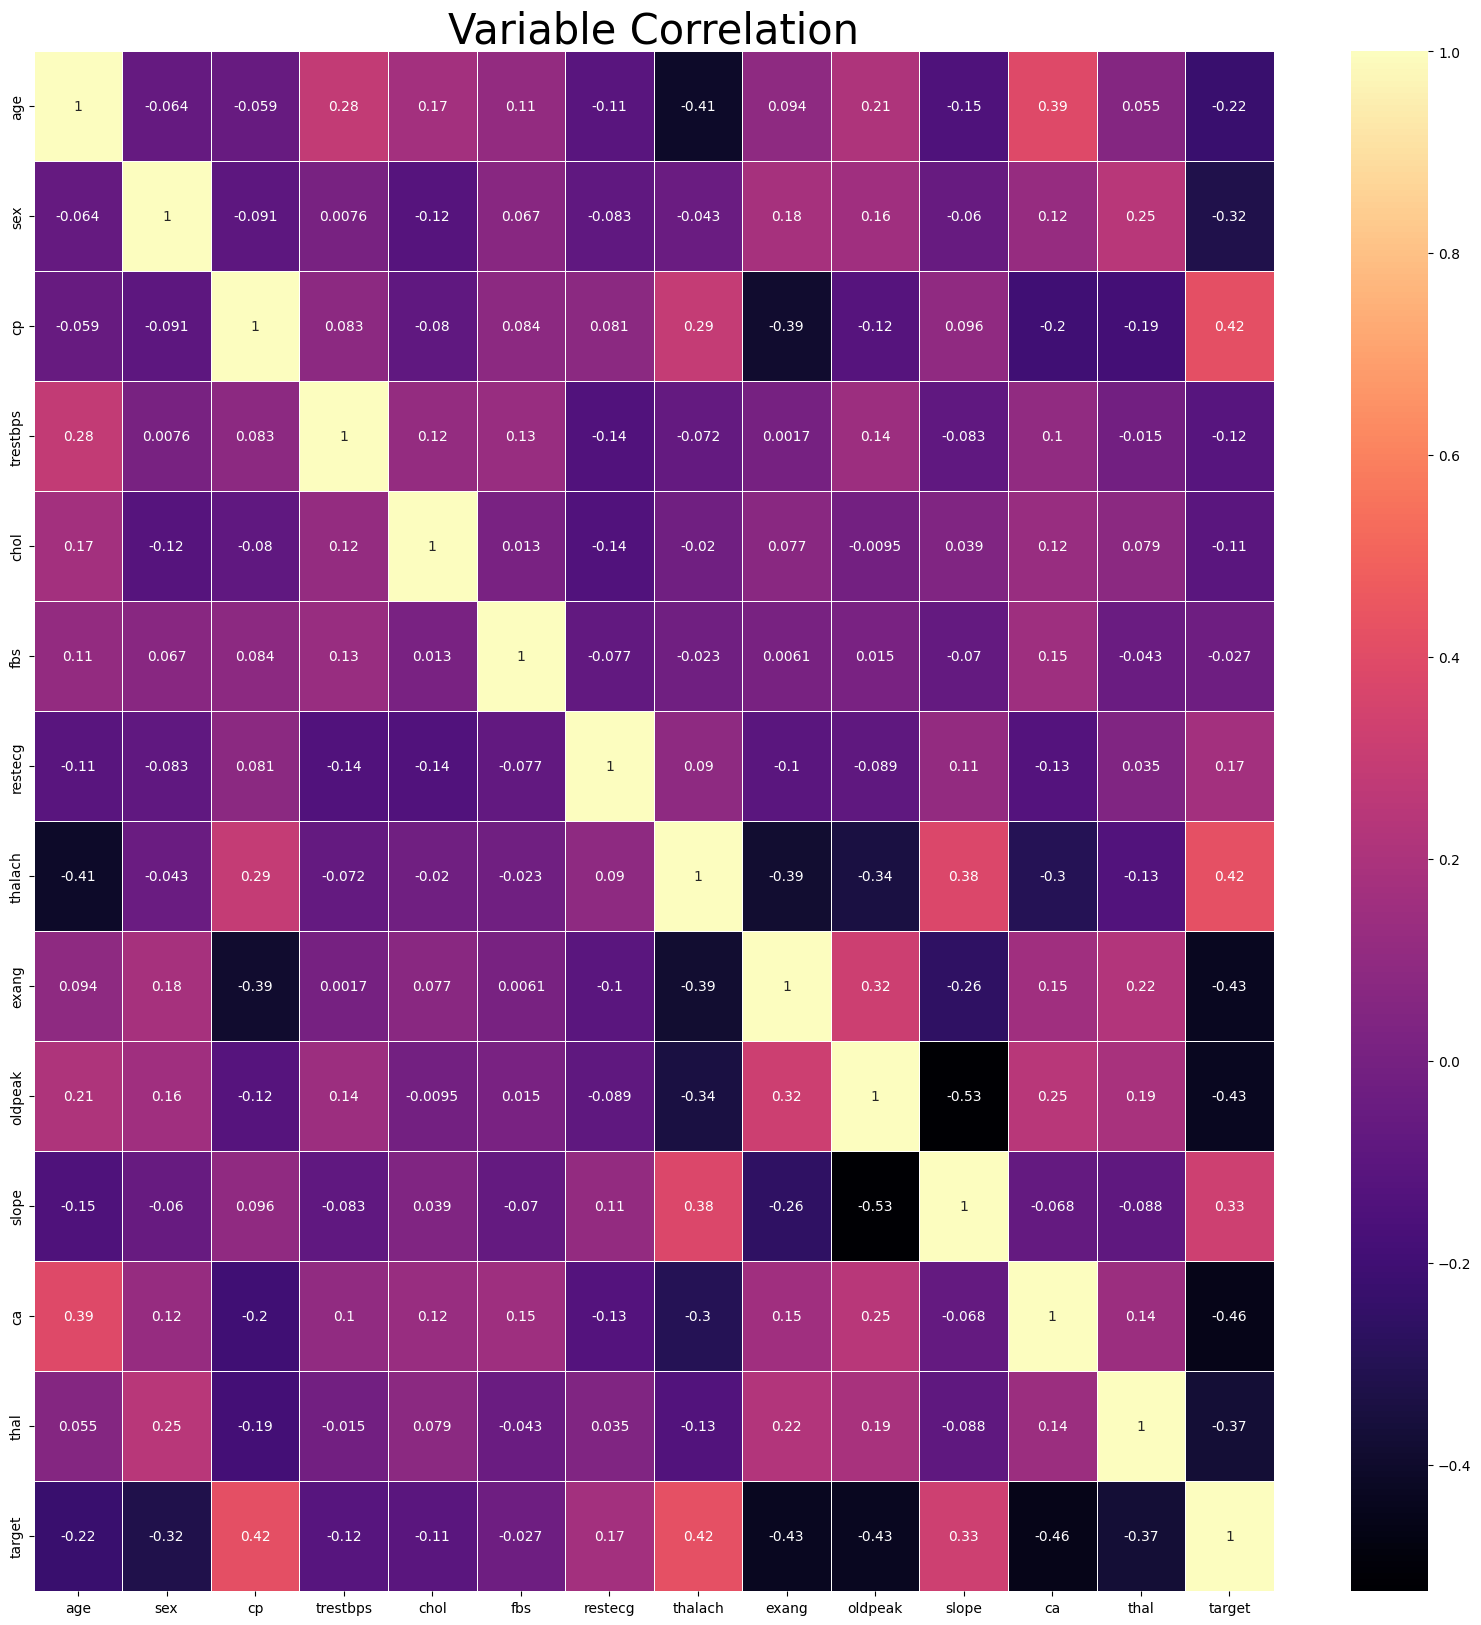

In [45]:
plt.figure(figsize=(20,20))
cor = df.corr()
sns.heatmap(cor,annot=True, linewidth=.5, cmap="magma")
plt.title('Variable Correlation', fontsize = 30)
plt.show()

In [46]:
cor_matrix = df.corr()
cor_matrix

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.000000,-0.064118,-0.058687,0.282669,0.171015,0.106885,-0.110517,-0.411108,0.093718,0.209254,-0.149095,0.392130,0.054752,-0.222416
sex,-0.064118,1.000000,-0.091357,0.007572,-0.123863,0.066692,-0.083290,-0.042981,0.182596,0.157352,-0.060014,0.122489,0.245682,-0.318896
cp,-0.058687,-0.091357,1.000000,0.083242,-0.080369,0.084389,0.080836,0.285605,-0.388610,-0.122582,0.095881,-0.202923,-0.188487,0.416319
trestbps,0.282669,0.007572,0.083242,1.000000,0.115138,0.127221,-0.139228,-0.071600,0.001726,0.144438,-0.083024,0.101059,-0.014615,-0.115614
chol,0.171015,-0.123863,-0.080369,0.115138,1.000000,0.013066,-0.142285,-0.020128,0.076547,-0.009534,0.039352,0.124800,0.078868,-0.105627
fbs,0.106885,0.066692,0.084389,0.127221,0.013066,1.000000,-0.077417,-0.023484,0.006080,0.015070,-0.069563,0.150552,-0.042766,-0.027210
restecg,-0.110517,-0.083290,0.080836,-0.139228,-0.142285,-0.077417,1.000000,0.089556,-0.104440,-0.089255,0.111841,-0.126825,0.035452,0.171453
thalach,-0.411108,-0.042981,0.285605,-0.071600,-0.020128,-0.023484,0.089556,1.000000,-0.387726,-0.341190,0.376494,-0.296480,-0.134498,0.422559
exang,0.093718,0.182596,-0.388610,0.001726,0.076547,0.006080,-0.104440,-0.387726,1.000000,0.318620,-0.259780,0.154768,0.223241,-0.431599
oldpeak,0.209254,0.157352,-0.122582,0.144438,-0.009534,0.015070,-0.089255,-0.341190,0.318620,1.000000,-0.525142,0.245318,0.189228,-0.434108


In [47]:
cor_matrix['target'].sort_values()

,target
ca,-0.456989
oldpeak,-0.434108
exang,-0.431599
thal,-0.370759
sex,-0.318896
age,-0.222416
trestbps,-0.115614
chol,-0.105627
fbs,-0.027210
restecg,0.171453


In [48]:
variabel = ['cp', 'thalach', 'slope', 'oldpeak', 'exang', 'ca', 'thal', 'sex', 'age' ]
analyze = df[variabel]

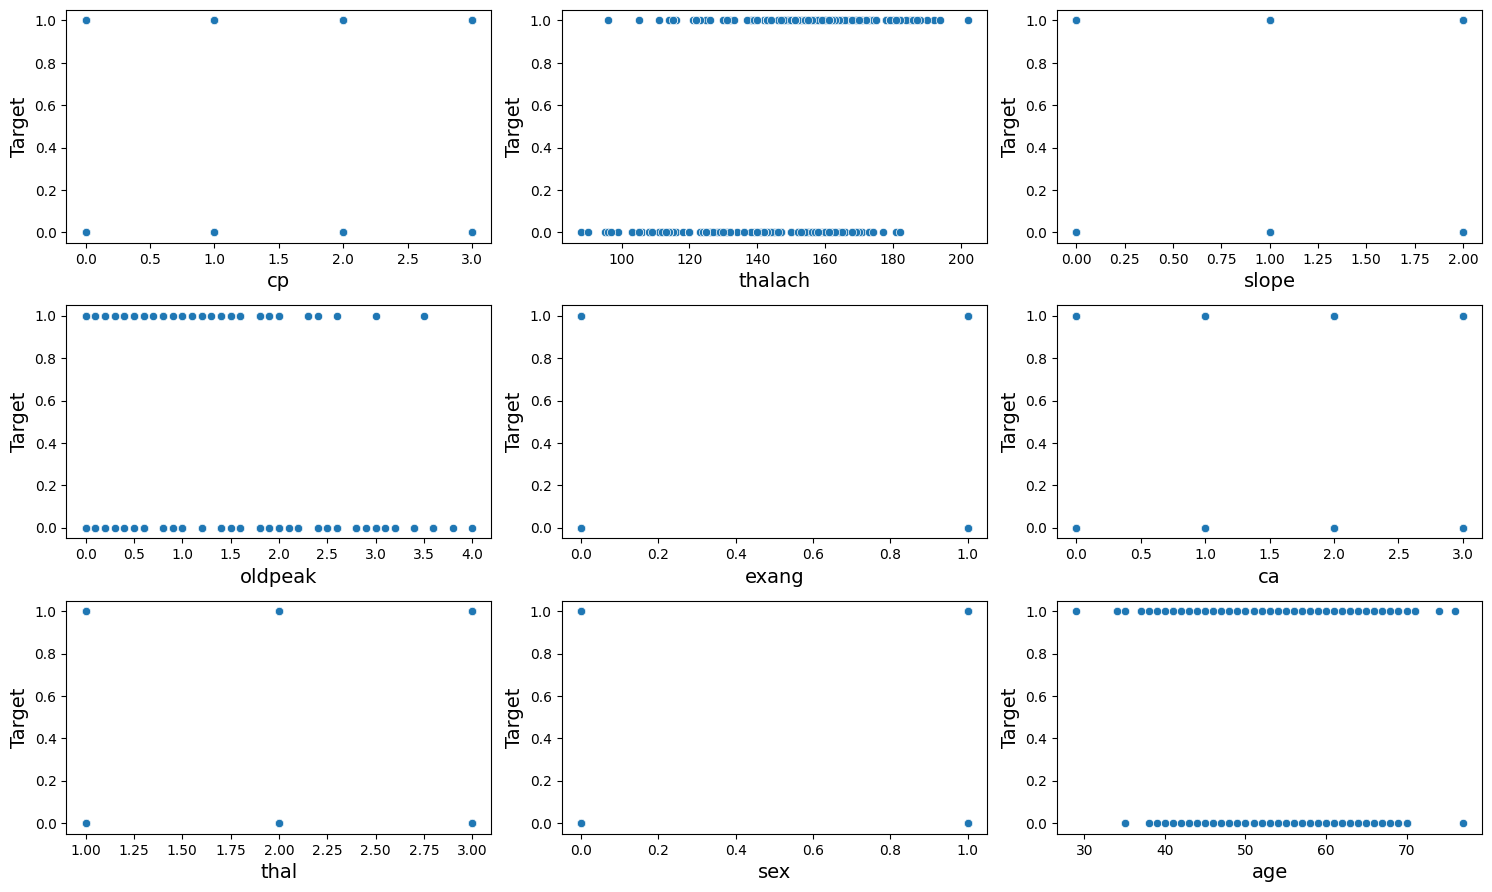

In [49]:
fig = plt.figure(figsize=(15,9))
for index in range(len(analyze.columns)):
    plt.subplot(3,3,index + 1)
    sns.scatterplot(x = analyze.iloc[:,index],y=df.target,data = analyze)
    plt.xlabel(analyze.columns[index], fontsize=14)
    plt.ylabel("Target", fontsize=14)

fig.tight_layout(pad = 1.0)

In [52]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df.drop("target", axis=1))

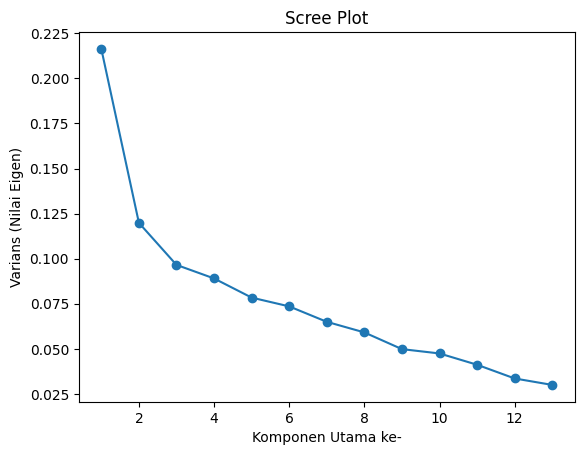

In [54]:
feature_number = len(X_scaled[0])
pca = PCA(n_components=feature_number)

pca.fit(X_scaled)

variance_ratio = pca.explained_variance_ratio_

cumulative_variance = np.cumsum(variance_ratio)

plt.plot(range(1, len(variance_ratio) + 1), variance_ratio, marker='o')
plt.xlabel('Komponen Utama ke-')
plt.ylabel('Varians (Nilai Eigen)')
plt.title('Scree Plot')
plt.show()

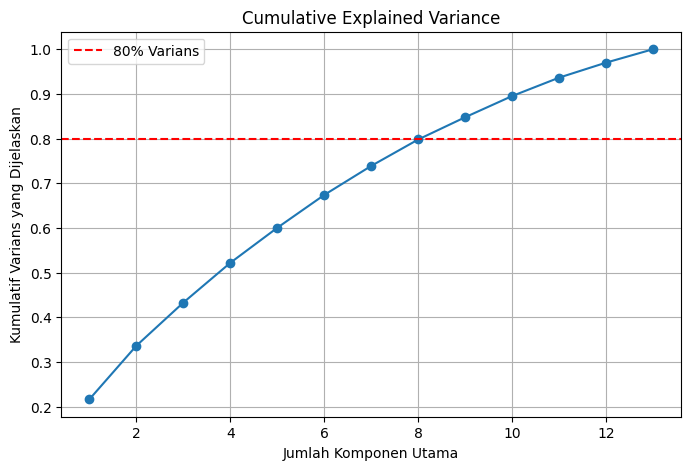

In [55]:
cumulative_variance = np.cumsum(variance_ratio)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='-')
plt.xlabel('Jumlah Komponen Utama')
plt.ylabel('Kumulatif Varians yang Dijelaskan')
plt.title('Cumulative Explained Variance')
plt.grid(True)
plt.axhline(y=0.80, color='r', linestyle='--', label='80% Varians')
plt.legend()
plt.show()

In [56]:
pca = PCA(n_components=8)
heart_data_reduced = pca.fit_transform(X_scaled)

In [57]:
# Melihat weight setiap feature dalam setiap principal component
feature_names = df.drop('target', axis=1).columns.to_list()
component_names = [f"PC{i+1}" for i in range(pca.n_components_)]

pca_components_df = pd.DataFrame(pca.components_, columns=feature_names, index=component_names)
pca_components_df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
PC1,-0.315473,-0.150813,0.269160,-0.142089,-0.096155,-0.074249,0.161235,0.426768,-0.367476,-0.397563,0.341589,-0.325065,-0.216250
PC2,0.432912,-0.297212,0.299894,0.450390,0.278125,0.294755,-0.207624,-0.000278,-0.288558,-0.074759,0.068707,0.204333,-0.297985
PC3,0.095034,-0.101257,-0.418146,-0.139990,0.516172,-0.191954,-0.083020,0.023197,0.119572,-0.364570,0.482586,0.232907,0.203021
PC4,-0.120352,0.662305,0.112060,0.158795,-0.057237,0.441250,-0.210503,0.280602,-0.047483,-0.073270,0.228268,0.197242,0.299055
PC5,0.324360,-0.005389,0.084185,-0.107365,-0.286373,0.089062,0.716159,-0.159939,-0.187290,-0.050168,0.198277,0.358161,0.206286
PC6,0.030454,0.046450,0.278585,0.398280,0.338051,-0.445922,0.206006,0.187145,-0.114004,0.228162,-0.066936,-0.203857,0.508919
PC7,-0.198367,-0.254118,0.035624,-0.182593,0.444599,0.636782,0.323025,0.084416,0.184341,0.039023,-0.210649,-0.184419,0.181513
PC8,-0.021764,0.015256,-0.312816,0.650940,-0.191592,0.115515,0.269055,-0.085326,0.363622,-0.223951,0.183054,-0.343448,-0.118970


In [58]:
for component, component_name in zip(pca.components_, component_names):
    feature_indices = component.argsort()[::-1]
    retained_features = [feature_names[idx] for idx in feature_indices[:5]]
    print(f"{component_name}: {retained_features}")

PC1: ['thalach', 'slope', 'cp', 'restecg', 'fbs']
PC2: ['trestbps', 'age', 'cp', 'fbs', 'chol']
PC3: ['chol', 'slope', 'ca', 'thal', 'exang']
PC4: ['sex', 'fbs', 'thal', 'thalach', 'slope']
PC5: ['restecg', 'ca', 'age', 'thal', 'slope']
PC6: ['thal', 'trestbps', 'chol', 'cp', 'oldpeak']
PC7: ['fbs', 'chol', 'restecg', 'exang', 'thal']
PC8: ['trestbps', 'exang', 'restecg', 'slope', 'fbs']


In [59]:
df = df[['sex','age','cp','thalach','slope','exang','ca','thal','oldpeak','target']]

In [60]:
df

,sex,age,cp,thalach,slope,exang,ca,thal,oldpeak,target
0,1,52,0,168,2,0,2,3,1.0,0
1,1,53,0,155,0,1,0,3,3.1,0
2,1,70,0,125,0,1,0,3,2.6,0
3,1,61,0,161,2,0,1,3,0.0,0
4,0,62,0,106,1,0,3,2,1.9,0
...,...,...,...,...,...,...,...,...,...,...
723,0,68,2,115,1,0,0,2,1.5,1
733,0,44,2,175,1,0,0,2,0.6,1
739,1,52,0,161,2,1,1,3,0.0,0
843,1,59,3,125,2,0,0,2,0.0,0


In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 283 entries, 0 to 878
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   sex      283 non-null    int64  
 1   age      283 non-null    int64  
 2   cp       283 non-null    int64  
 3   thalach  283 non-null    int64  
 4   slope    283 non-null    int64  
 5   exang    283 non-null    int64  
 6   ca       283 non-null    int64  
 7   thal     283 non-null    int64  
 8   oldpeak  283 non-null    float64
 9   target   283 non-null    int64  
dtypes: float64(1), int64(9)
memory usage: 24.3 KB


In [62]:
df.to_csv('heart_disease_clean')
files.download('heart_disease_clean')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>